### build a basic chatbot

In [1]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages


d:\gen ai\firstLanggraph\.venv\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [2]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]


graph_builder=StateGraph(State)    

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()
from langchain.chat_models import init_chat_model


model="llama3-8b-8192"
llm=init_chat_model("groq:llama-3.3-70b-versatile")
llm


ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001D0DECDAD50>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001D0DEE4EAD0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [4]:
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [5]:
graph_builder=StateGraph(State)

## Adding node
graph_builder.add_node("llmchatbot",chatbot)
## Adding Edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

## compile the graph
graph=graph_builder.compile()

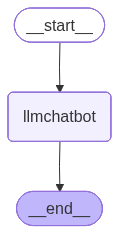

In [6]:
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [20]:
response=graph.invoke({"messages":"sup"})

In [21]:
response

{'messages': [HumanMessage(content='sup', additional_kwargs={}, response_metadata={}, id='6c2815d1-083b-492e-9938-4bac7a918eea'),
  AIMessage(content="Not much, just here to help. What's up with you?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 36, 'total_tokens': 51, 'completion_time': 0.049007656, 'completion_tokens_details': None, 'prompt_time': 0.004716442, 'prompt_tokens_details': None, 'queue_time': 0.785995235, 'total_time': 0.053724098}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e08de-12ee-7f52-9893-3ffa295b29d5-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 15, 'total_tokens': 51})]}

In [28]:
for event in graph.stream({"messages":"why is cristiano better than messi"}):
    for value in event.values():
        print(value["messages"][-1].content)

A question that sparks a lot of debate among football fans. While both Cristiano Ronaldo and Lionel Messi are widely regarded as two of the greatest football players of all time, opinions on who is "better" tend to be subjective and often influenced by personal biases, team loyalties, and individual preferences. Here's a balanced analysis of both players' strengths and achievements:

**Cristiano Ronaldo's advantages:**

1. **Physicality and athleticism**: Ronaldo is known for his exceptional speed, power, and agility, which allows him to dominate games with his pace and strength.
2. **Goal-scoring consistency**: Ronaldo has consistently scored at an incredible rate throughout his career, with an average of over 40 goals per season.
3. **Trophy cabinet**: Ronaldo has won an impressive array of trophies, including five Ballon d'Or awards, four UEFA Champions League titles, and numerous league and cup titles with Manchester United, Real Madrid, and Juventus.
4. **Adaptability**: Ronaldo h